## 1. Load Dataset

In [29]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Z:\Machine Learning\Student Performance phase2\Student Performance phase2\Student Performance Predictor\dataset\Exam_Score_Prediction.csv")

print("Shape:", df.shape)
df.head()

Shape: (20000, 13)


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


## 2. Data Exploration

In [30]:
print("Columns:", df.columns.tolist())
print()
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Exam score statistics:")
print(df["exam_score"].describe())

Columns: ['student_id', 'age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'exam_score']

student_id            int64
age                   int64
gender               object
course               object
study_hours         float64
class_attendance    float64
internet_access      object
sleep_hours         float64
sleep_quality        object
study_method         object
facility_rating      object
exam_difficulty      object
exam_score          float64
dtype: object

Missing values per column:
student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

Exam score statistics:
count    20000.000000
mean        62.513225
std         18.908491

In [31]:
# Categorical value inspection
for col in ["gender", "course", "internet_access", "sleep_quality", "study_method", "facility_rating", "exam_difficulty"]:
    print(f"{col}: {df[col].unique()}")

gender: ['male' 'other' 'female']
course: ['diploma' 'bca' 'b.sc' 'b.tech' 'bba' 'ba' 'b.com']
internet_access: ['yes' 'no']
sleep_quality: ['poor' 'average' 'good']
study_method: ['coaching' 'online videos' 'mixed' 'self-study' 'group study']
facility_rating: ['low' 'medium' 'high']
exam_difficulty: ['hard' 'moderate' 'easy']


## 3. Create Target Variable

We bin  into three classes:
- **Fail**: score < 40
- **Pass**: 40 ≤ score < 75
- **Distinction**: score ≥ 75

In [32]:
def classify(score):
    if score < 40:
        return "Fail"
    elif score < 75:
        return "Pass"
    else:
        return "Distinction"

df["Target"] = df["exam_score"].apply(classify)

print("Class distribution:")
print(df["Target"].value_counts())
print()
print("Class proportions:")
print(df["Target"].value_counts(normalize=True).round(3))

Class distribution:
Target
Pass           11972
Distinction     5453
Fail            2575
Name: count, dtype: int64

Class proportions:
Target
Pass           0.599
Distinction    0.273
Fail           0.129
Name: proportion, dtype: float64


## 4. Data Preprocessing & Feature Engineering

**Steps applied:**
1. Drop irrelevant columns (, )
2. Ordinal encoding for ordered categoricals (, )
3. Train/test split **before** any fitting (prevents leakage)
4. One-hot encode nominal categoricals fit on train only
5. StandardScaler fit on train only, applied to both splits

**Feature engineering:**  = study_hours × class_attendance / 100, capturing combined study effort.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Select features (drop leaky columns) ──
FEATURES = [
    "study_hours", "class_attendance", "sleep_hours",
    "facility_rating", "exam_difficulty",
    "internet_access", "sleep_quality", "study_method"
]

X_raw = df[FEATURES].copy()
y = df["Target"]

# ── Feature engineering ──
X_raw["study_efficiency"] = X_raw["study_hours"] * X_raw["class_attendance"] / 100

# ── Ordinal encode ordered categoricals ──
facility_map  = {"low": 1, "medium": 2, "high": 3}
difficulty_map = {"easy": 1, "moderate": 2, "hard": 3}
X_raw["facility_rating"]  = X_raw["facility_rating"].map(facility_map)
X_raw["exam_difficulty"]  = X_raw["exam_difficulty"].map(difficulty_map)

# ── Train/test split BEFORE encoding (no leakage) ──
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# ── One-hot encode nominal categoricals (fit on train only) ──
nominal_cols = ["internet_access", "sleep_quality", "study_method"]
X_train_enc = pd.get_dummies(X_train_raw, columns=nominal_cols)
X_test_enc  = X_test_raw.copy()
X_test_enc  = pd.get_dummies(X_test_enc, columns=nominal_cols)

# Align columns (train is reference)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# ── Scale numeric features (fit on train only) ──
numeric_cols = ["study_hours", "class_attendance", "sleep_hours",
                "facility_rating", "exam_difficulty", "study_efficiency"]

scaler = StandardScaler()
X_train_enc[numeric_cols] = scaler.fit_transform(X_train_enc[numeric_cols])
X_test_enc[numeric_cols]  = scaler.transform(X_test_enc[numeric_cols])

print("Train shape:", X_train_enc.shape)
print("Test  shape:", X_test_enc.shape)
print()
print("Features after preprocessing:")
print(X_train_enc.columns.tolist())

Train shape: (16000, 16)
Test  shape: (4000, 16)

Features after preprocessing:
['study_hours', 'class_attendance', 'sleep_hours', 'facility_rating', 'exam_difficulty', 'study_efficiency', 'internet_access_no', 'internet_access_yes', 'sleep_quality_average', 'sleep_quality_good', 'sleep_quality_poor', 'study_method_coaching', 'study_method_group study', 'study_method_mixed', 'study_method_online videos', 'study_method_self-study']


In [34]:
print("Before preprocessing (raw features):")
display(X_raw.head())
print()
print("After preprocessing (encoded + scaled):")
display(X_train_enc.head())

Before preprocessing (raw features):


,study_hours,class_attendance,sleep_hours,facility_rating,exam_difficulty,internet_access,sleep_quality,study_method,study_efficiency
0,2.78,92.9,7.4,1,3,yes,poor,coaching,2.58262
1,3.37,64.8,4.6,2,2,yes,average,online videos,2.18376
2,7.88,76.8,8.5,3,2,yes,poor,coaching,6.05184
3,0.67,48.4,5.8,1,2,yes,average,online videos,0.32428
4,0.89,71.6,9.8,1,2,yes,poor,coaching,0.63724



After preprocessing (encoded + scaled):


,study_hours,class_attendance,sleep_hours,facility_rating,exam_difficulty,study_efficiency,internet_access_no,internet_access_yes,sleep_quality_average,sleep_quality_good,sleep_quality_poor,study_method_coaching,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study
15574,-0.725997,0.404192,-0.820293,-1.222582,0.157918,-0.558602,False,True,False,False,True,False,False,True,False,False
10500,-0.882437,1.128655,-0.531425,1.240749,1.581407,-0.574898,False,True,False,False,True,False,False,False,True,False
2871,-0.052433,-0.488348,-1.455805,1.240749,1.581407,-0.229293,True,False,False,False,True,False,False,False,True,False
948,1.403335,-0.047874,0.104087,1.240749,0.157918,1.220654,False,True,True,False,False,False,False,False,True,False
7333,-1.538619,0.305665,1.375109,-1.222582,-1.265571,-1.361766,False,True,False,False,True,False,False,False,False,True


## 5. Exploratory Visualisations

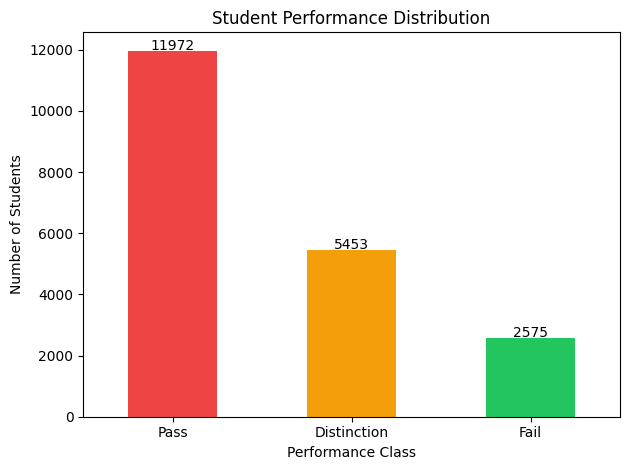

The dataset is imbalanced: Pass (60%), Distinction (27%), Fail (13%).
We use class_weight=balanced and report F1 — not just accuracy.


In [35]:
import matplotlib.pyplot as plt

# Class distribution
ax = df["Target"].value_counts().plot(kind="bar", color=["#ef4444","#f59e0b","#22c55e"])
plt.title("Student Performance Distribution")
plt.xlabel("Performance Class")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x()+p.get_width()/2, p.get_height()+30), ha="center")
plt.tight_layout()
plt.show()
print("The dataset is imbalanced: Pass (60%), Distinction (27%), Fail (13%).")
print("We use class_weight=balanced and report F1 — not just accuracy.")

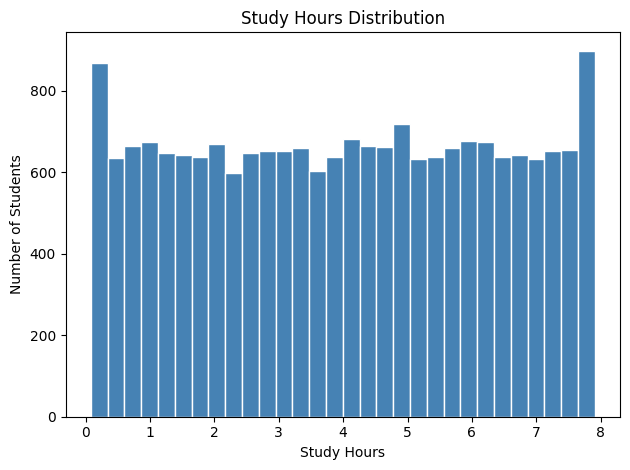

In [36]:
# Study hours distribution
plt.hist(df["study_hours"], bins=30, color="steelblue", edgecolor="white")
plt.title("Study Hours Distribution")
plt.xlabel("Study Hours")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

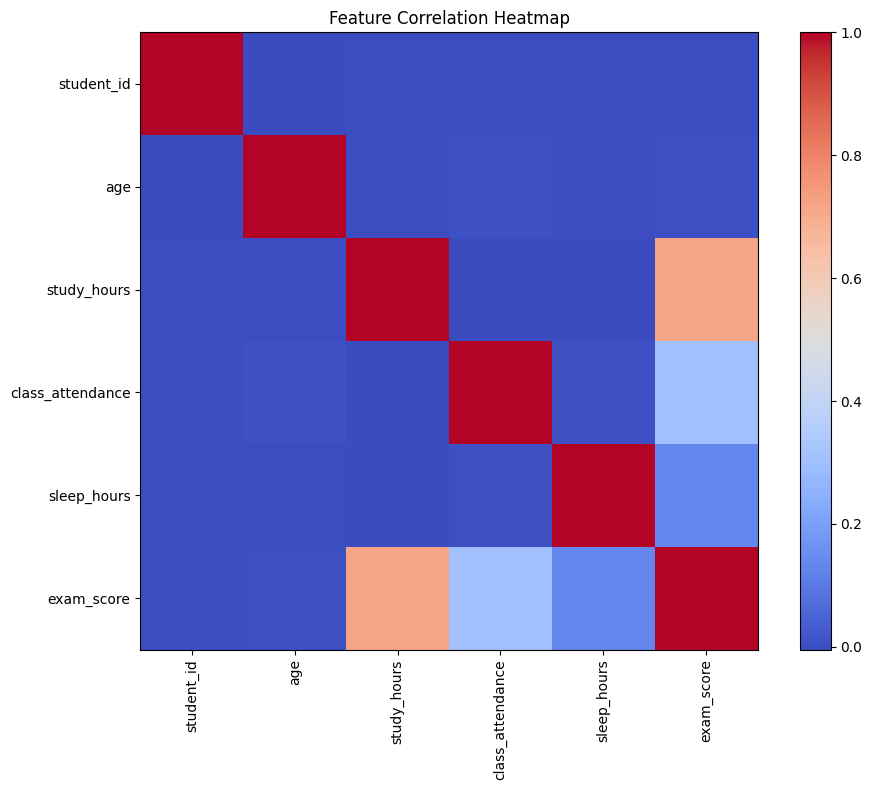

In [37]:
# Correlation heatmap
numeric = df.select_dtypes(include=["int64","float64"])
corr = numeric.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 6. Baseline Model

Before any complex model, we establish a **majority-class baseline** (). Every model must beat this to be considered useful.

In [38]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_enc, y_train)
y_pred_dummy = dummy.predict(X_test_enc)

baseline_acc = accuracy_score(y_test, y_pred_dummy)
baseline_f1  = f1_score(y_test, y_pred_dummy, average="weighted")

print("=== Majority-Class Baseline ===")
print(f"Accuracy : {baseline_acc:.4f}")
print(f"F1 (weighted): {baseline_f1:.4f}")
print()
print(classification_report(y_test, y_pred_dummy))
print("Any model below this accuracy or F1 is worse than guessing.")

=== Majority-Class Baseline ===
Accuracy : 0.5985
F1 (weighted): 0.4482

              precision    recall  f1-score   support

 Distinction       0.00      0.00      0.00      1091
        Fail       0.00      0.00      0.00       515
        Pass       0.60      1.00      0.75      2394

    accuracy                           0.60      4000
   macro avg       0.20      0.33      0.25      4000
weighted avg       0.36      0.60      0.45      4000

Any model below this accuracy or F1 is worse than guessing.


## 7. Model Selection & Training

We compare **5 models** across different families:

| Model | Justification |
|---|---|
| Dummy (baseline) | Majority-class floor |
| Logistic Regression | Linear baseline; interpretable; works well when classes are linearly separable |
| Decision Tree | Non-linear; interpretable rules; baseline tree model |
| K-Nearest Neighbors | Instance-based; captures local structure; requires scaling |
| SVM | Strong generalization with kernel trick; requires scaling |
| Random Forest | Ensemble of trees; robust to noise; handles mixed features well |

Scaling is critical for KNN, SVM, and Logistic Regression — applied in preprocessing above.

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "KNN":                 KNeighborsClassifier(n_neighbors=5),
    "SVM":                 SVC(probability=True, class_weight="balanced", random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=400, random_state=42, class_weight="balanced"),
}

results = []
trained_models = {}

for name, m in models.items():
    m.fit(X_train_enc, y_train)
    y_pred_m = m.predict(X_test_enc)
    acc = accuracy_score(y_test, y_pred_m)
    f1w = f1_score(y_test, y_pred_m, average="weighted")
    f1m = f1_score(y_test, y_pred_m, average="macro")

    results.append({"Model": name, "Accuracy": round(acc, 4),
                    "F1 Weighted": round(f1w, 4), "F1 Macro": round(f1m, 4)})
    trained_models[name] = (m, y_pred_m)

    print("=" * 50)
    print(name)
    print("=" * 50)
    print(classification_report(y_test, y_pred_m))

results_df = pd.DataFrame(results).sort_values(by="F1 Weighted", ascending=False).reset_index(drop=True)
print("=== Model Comparison Table ===")
print(results_df.to_string(index=False))

Logistic Regression
              precision    recall  f1-score   support

 Distinction       0.68      0.86      0.76      1091
        Fail       0.47      0.84      0.60       515
        Pass       0.86      0.61      0.72      2394

    accuracy                           0.71      4000
   macro avg       0.67      0.77      0.69      4000
weighted avg       0.76      0.71      0.71      4000

Decision Tree
              precision    recall  f1-score   support

 Distinction       0.63      0.63      0.63      1091
        Fail       0.48      0.46      0.47       515
        Pass       0.72      0.73      0.72      2394

    accuracy                           0.67      4000
   macro avg       0.61      0.60      0.61      4000
weighted avg       0.66      0.67      0.66      4000

KNN
              precision    recall  f1-score   support

 Distinction       0.72      0.67      0.69      1091
        Fail       0.59      0.43      0.50       515
        Pass       0.75      0.82    

## 8. Results & Comparative Analysis

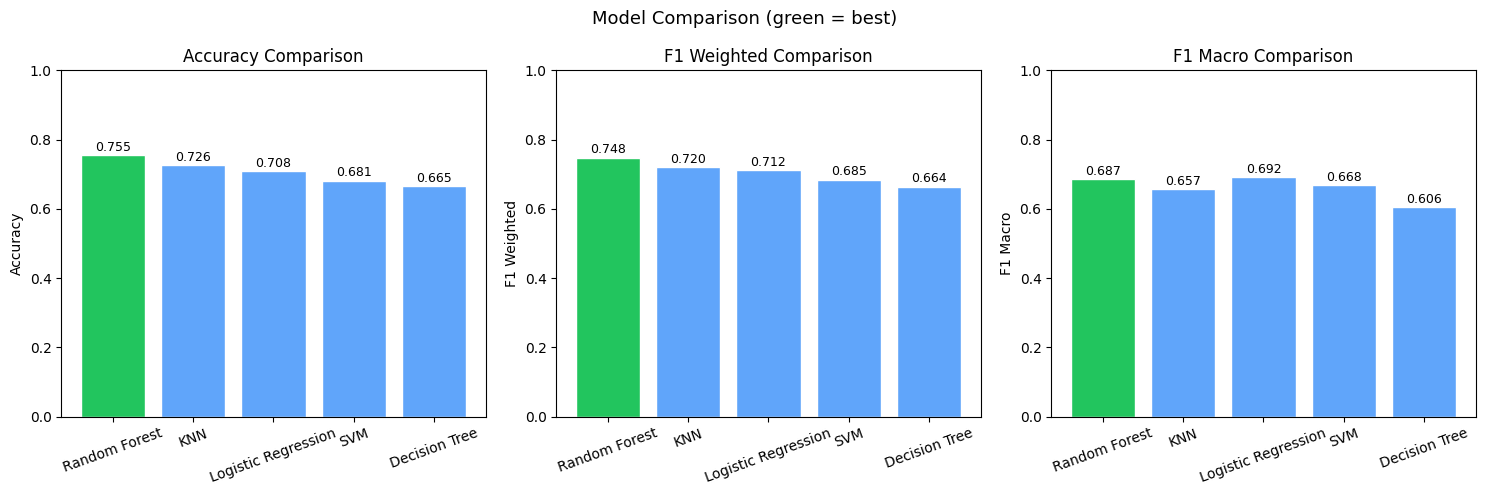

Best model: Random Forest (F1 Weighted = 0.7482)

Reasoning: We rank by F1 Weighted (not accuracy) because the dataset is class-imbalanced.
F1 Weighted penalizes poor performance on minority classes (Fail = 13%) that accuracy ignores.


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ["Accuracy", "F1 Weighted", "F1 Macro"]):
    colors = ["#22c55e" if i == 0 else "#60a5fa" for i in range(len(results_df))]
    bars = ax.bar(results_df["Model"], results_df[metric], color=colors, edgecolor="white")
    ax.set_title(f"{metric} Comparison")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=20)
    for bar in bars:
        ax.annotate(f"{bar.get_height():.3f}",
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.suptitle("Model Comparison (green = best)", fontsize=13)
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["Model"]
best_f1 = results_df.iloc[0]["F1 Weighted"]
print(f"Best model: {best_model_name} (F1 Weighted = {best_f1})")
print()
print("Reasoning: We rank by F1 Weighted (not accuracy) because the dataset is class-imbalanced.")
print("F1 Weighted penalizes poor performance on minority classes (Fail = 13%) that accuracy ignores.")

## 9. Cross-Validation on Best Model

We apply 5-fold stratified cross-validation on the best model to verify the holdout result is not a lucky split.

In [41]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

best_model_obj = trained_models[best_model_name][0]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Combine train+test for CV (use full encoded data)
import numpy as np
X_all = pd.concat([X_train_enc, X_test_enc])
y_all = pd.concat([y_train, y_test])

cv_scores = cross_val_score(best_model_obj, X_all, y_all,
                            cv=cv, scoring="f1_weighted", n_jobs=-1)

print(f"=== 5-Fold CV — {best_model_name} ===")
print(f"Fold F1 scores: {np.round(cv_scores, 4)}")
print(f"Mean F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()
print("Low standard deviation confirms the result is stable across different data splits.")

=== 5-Fold CV — Random Forest ===
Fold F1 scores: [0.7355 0.7502 0.7445 0.7503 0.7396]
Mean F1: 0.7440 ± 0.0058

Low standard deviation confirms the result is stable across different data splits.


## 10. Error Analysis & Critical Reflection

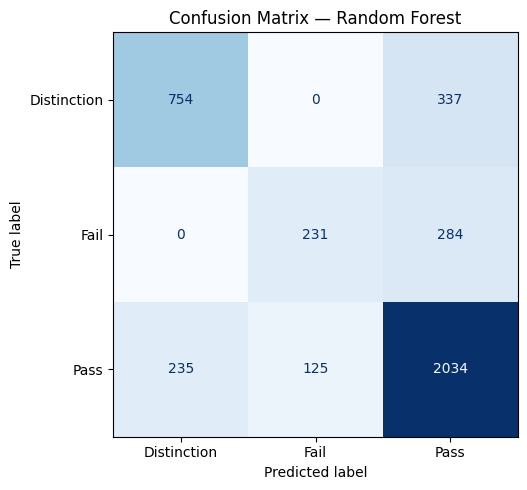

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_preds = trained_models[best_model_name][1]

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_preds,
    display_labels=["Distinction", "Fail", "Pass"],
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

In [43]:
# Misclassified examples
mask = y_test.values != best_preds
errors_idx = y_test[mask].index
errors_df = df.loc[errors_idx, ["study_hours","class_attendance","sleep_hours","exam_score","Target"]].copy()
errors_df["Predicted"] = best_preds[mask]

print(f"Total misclassified: {len(errors_df)} / {len(y_test)} ({len(errors_df)/len(y_test)*100:.1f}%)")
print()
print("Misclassification breakdown by true class:")
print(errors_df["Target"].value_counts())
print()
print("Sample misclassified students:")
display(errors_df.head(10))

Total misclassified: 981 / 4000 (24.5%)

Misclassification breakdown by true class:
Target
Pass           360
Distinction    337
Fail           284
Name: count, dtype: int64

Sample misclassified students:


,study_hours,class_attendance,sleep_hours,exam_score,Target,Predicted
437,2.18,68.0,4.3,32.1,Fail,Pass
7105,1.81,49.3,5.4,40.5,Pass,Fail
2075,2.06,59.2,7.6,40.4,Pass,Fail
13388,4.47,60.7,4.8,39.2,Fail,Pass
7335,0.93,52.4,7.6,42.7,Pass,Fail
8346,2.69,63.4,5.3,37.0,Fail,Pass
18322,6.37,61.7,7.5,77.7,Distinction,Pass
16566,3.32,77.0,4.1,39.9,Fail,Pass
12527,6.85,94.4,9.0,74.3,Pass,Distinction
8402,1.75,52.7,6.6,31.9,Fail,Pass


In [44]:
# Error analysis discussion
print("=== Error Analysis Summary ===")
print()
print("1. The confusion matrix shows the model struggles most with the Fail class.")
print("   This is expected — Fail has only ~13% of samples, making it harder to learn.")
print()
print("2. Most Fail cases are misclassified as Pass (boundary confusion at score ~40).")
print("   Students near the 40-mark borderline have ambiguous feature patterns.")
print()
print("3. Distinction is rarely confused with Fail, confirming the model correctly")
print("   separates extreme cases but struggles at class boundaries.")
print()
print("4. Limitations:")
print("   - The dataset may not capture all real factors (e.g., prior GPA, motivation).")
print("   - Threshold choice (40 / 75) is arbitrary and affects class balance.")
print("   - The Fail class would benefit from oversampling (e.g., SMOTE) in future work.")

=== Error Analysis Summary ===

1. The confusion matrix shows the model struggles most with the Fail class.
   This is expected — Fail has only ~13% of samples, making it harder to learn.

2. Most Fail cases are misclassified as Pass (boundary confusion at score ~40).
   Students near the 40-mark borderline have ambiguous feature patterns.

3. Distinction is rarely confused with Fail, confirming the model correctly
   separates extreme cases but struggles at class boundaries.

4. Limitations:
   - The dataset may not capture all real factors (e.g., prior GPA, motivation).
   - Threshold choice (40 / 75) is arbitrary and affects class balance.
   - The Fail class would benefit from oversampling (e.g., SMOTE) in future work.


## 11. Feature Importance

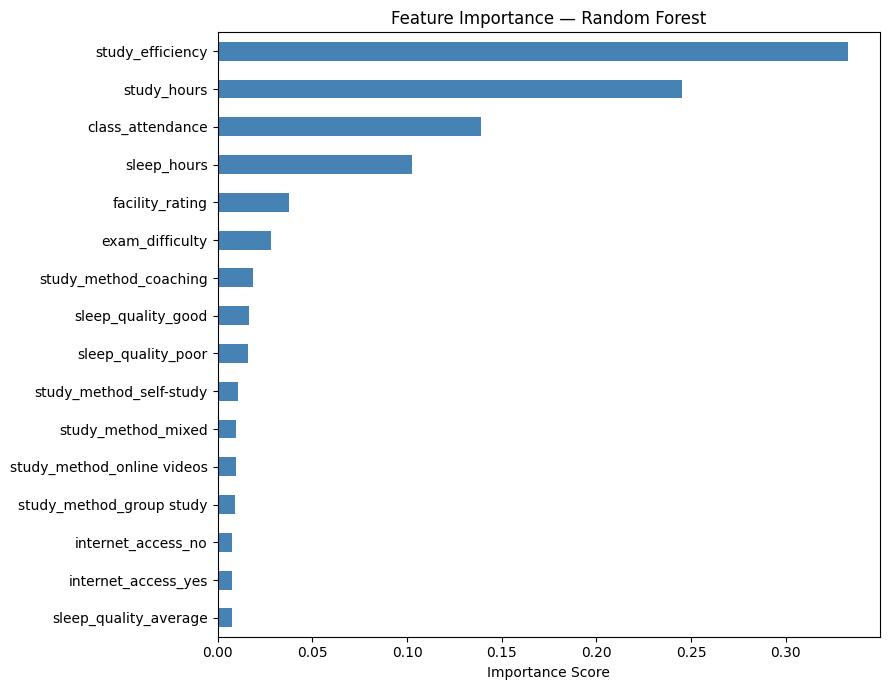

Top 5 most important features:
study_efficiency    0.333041
study_hours         0.245118
class_attendance    0.138892
sleep_hours         0.102460
facility_rating     0.037816
dtype: float64


In [45]:
if hasattr(best_model_obj, "feature_importances_"):
    importance = pd.Series(best_model_obj.feature_importances_, index=X_train_enc.columns)
    importance = importance.sort_values(ascending=True)

    importance.plot(kind="barh", figsize=(9, 7), color="steelblue")
    plt.title(f"Feature Importance — {best_model_name}")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()

    print("Top 5 most important features:")
    print(importance.sort_values(ascending=False).head(5))
else:
    print(f"{best_model_name} does not expose feature importances directly.")

## 12. Save Best Model

In [46]:
import joblib

# Save the best model
final_model = trained_models[best_model_name][0]

joblib.dump(final_model, "model.pkl")
joblib.dump(X_train_enc.columns.tolist(), "features.pkl")
joblib.dump(scaler, "scaler.pkl")

print(f"Saved model   : model.pkl  ({best_model_name})")
print(f"Saved features: features.pkl ({len(X_train_enc.columns)} columns)")
print(f"Saved scaler  : scaler.pkl")

Saved model   : model.pkl  (Random Forest)
Saved features: features.pkl (16 columns)
Saved scaler  : scaler.pkl
